In [ ]:
# Train Retrieval-Augmented Classification (RAC) Model
This notebook trains the RAC model on TaoWu dataset using retrieval from the knowledge base.

**Purpose:**
- Train attention and classification layers to utilize retrieved neighbors
- The encoder remains frozen (uses knowledge from Script 02)
- Compares target subjects with similar cases from knowledge base

# Import necessary libraries
import os
import torch
import pandas as pd
import numpy as np
import faiss  # For nearest neighbor retrieval
import matplotlib.pyplot as plt
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
from models import GraphAutoencoder, AttentionMechanism, RAC_Model
from utils import FCDataset

# ===== DEFINE FILE PATHS =====
output_dir = r'C:\Users\danie\Documents\Projects\Master thesis\Tara\Scripts\Outputs'
master_csv = os.path.join(output_dir, "master_metadata.csv")
encoder_weights = os.path.join(output_dir, 'gae_encoder.pth')  # Pre-trained encoder
index_path = os.path.join(output_dir, 'knowledge_base.index')  # FAISS index from Script 03
kb_embeddings_path = os.path.join(output_dir, 'kb_embeddings.npy')  # Embedding vectors
kb_metadata_path = os.path.join(output_dir, 'kb_metadata_indexed.csv')  # Metadata for KB

# ===== LOAD AND SPLIT TARGET DATA =====
# Load master metadata
df = pd.read_csv(master_csv)

# Extract TaoWu dataset as target (subjects we want to classify)
df_target = df[df['dataset_source'] == 'TaoWu'].reset_index(drop=True)

# ===== CREATE TRAIN/VALIDATION SPLIT =====
# 80/20 split stratified by label (maintains class balance)
# random_state=42 ensures reproducibility
# Training set: Used to train attention and classification layers
# Validation set: Used to monitor overfitting and tune hyperparameters
df_train, df_val = train_test_split(df_target, test_size=0.2, stratify=df_target['label'], random_state=42)

# ===== CREATE DATALOADERS =====
# Training loader: batch_size=16, shuffle=True for randomization
train_loader = DataLoader(FCDataset(df_train), batch_size=16, shuffle=True)

# Validation loader: batch_size=16, shuffle=False to maintain order
val_loader = DataLoader(FCDataset(df_val), batch_size=16, shuffle=False)

# ===== LOAD PRE-TRAINED ENCODER =====
# Initialize GraphAutoencoder with same architecture as Script 02
base_model = GraphAutoencoder(num_nodes=100, input_dim=100, hidden_dim=64, embedding_dim=128)

# Load pre-trained encoder weights (knowledge from PPMI + Neurocon)
base_model.encoder.load_state_dict(torch.load(encoder_weights))

# Extract just the encoder component
gae_encoder = base_model.encoder

# Keep encoder frozen initially
# This preserves the learned representations from the knowledge base
gae_encoder.eval()

# ===== LOAD FAISS INDEX AND EMBEDDINGS =====
# Load FAISS index for fast nearest neighbor search
index = faiss.read_index(index_path)

# Load pre-computed embeddings (the "shelf" of knowledge base vectors)
kb_embeddings = np.load(kb_embeddings_path).astype('float32')

# K = number of nearest neighbors to retrieve for each query
K = 10  # Retrieve 10 most similar cases from knowledge base

# ===== INITIALIZE RAC MODEL =====
# Initialize attention mechanism (learns to weight retrieved neighbors)
attention = AttentionMechanism(embedding_dim=128)

# Initialize RAC model (combines encoder, attention, and classifier)
rac_model = RAC_Model(gae_encoder, attention, embedding_dim=128)

# ===== TRAINING SETUP =====
# Optimizer: Updates attention and classification weights (encoder frozen)
optimizer = torch.optim.Adam(rac_model.parameters(), lr=0.001)

# Learning rate scheduler: Reduces LR when validation loss plateaus
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# Loss function: Binary Cross Entropy for binary classification
loss_fn = torch.nn.BCELoss()

# ===== TRAINING LOOP =====
num_epochs = 50
train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    # ===== TRAINING PHASE =====
    rac_model.train()  # Enable training mode (dropout, etc.)
    total_train_loss = 0
    
    for data, labels in train_loader:
        optimizer.zero_grad()  # Reset gradients
        
        # ===== STEP A: GENERATE QUERY EMBEDDING =====
        # Encode target subject using frozen GAE encoder
        # No gradients needed for encoder (it stays frozen)
        with torch.no_grad():
            v_query = gae_encoder(data.x, data.edge_index, data.edge_weight, data.batch)
        
        # ===== STEP B: RETRIEVE NEAREST NEIGHBORS FROM FAISS =====
        # Convert query to NumPy for FAISS
        v_query_np = v_query.cpu().numpy().astype('float32')
        
        # Search FAISS index for K nearest neighbors
        # distances: L2 distances to neighbors
        # neighbor_indices: Indices of neighbors in kb_embeddings
        distances, neighbor_indices = index.search(v_query_np, K)
        
        # ===== STEP C: GET RETRIEVED EMBEDDING VECTORS =====
        # Map indices back to actual embedding vectors
        # v_retrieved shape: (batch_size, K, 128)
        v_retrieved = torch.from_numpy(kb_embeddings[neighbor_indices]).to(v_query.device)
        
        # ===== STEP D: FORWARD PASS THROUGH RAC MODEL =====
        # RAC model uses attention to combine query with retrieved neighbors
        # predictions: Probability of PD (0 to 1)
        # attention_weights: How much each neighbor contributed
        predictions, _ = rac_model(data.x, data.edge_index, data.edge_weight, data.batch, v_retrieved)
        
        # ===== STEP E: CALCULATE LOSS AND UPDATE =====
        # Compare predictions with ground truth labels
        loss = loss_fn(predictions.squeeze(), labels.float())
        
        # Backpropagation
        loss.backward()
        
        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(rac_model.parameters(), max_norm=1.0)
        
        # Update model weights
        optimizer.step()
        
        total_train_loss += loss.item()

    # Calculate average training loss for this epoch
    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # ===== VALIDATION PHASE =====
    rac_model.eval()  # Disable dropout, etc.
    total_val_loss = 0
    correct = 0
    total = 0
    
    # No gradient computation needed for validation
    with torch.no_grad():
        for data, labels in val_loader:
            # ===== GENERATE QUERY EMBEDDING =====
            v_query = gae_encoder(data.x, data.edge_index, data.edge_weight, data.batch)
            
            # ===== RETRIEVE NEIGHBORS =====
            v_query_np = v_query.cpu().numpy().astype('float32')
            distances, neighbor_indices = index.search(v_query_np, K)
            v_retrieved = torch.from_numpy(kb_embeddings[neighbor_indices]).to(v_query.device)
            
            # ===== FORWARD PASS =====
            predictions, _ = rac_model(data.x, data.edge_index, data.edge_weight, data.batch, v_retrieved)
            
            # ===== CALCULATE LOSS =====
            loss = loss_fn(predictions.squeeze(), labels.float())
            total_val_loss += loss.item()
            
            # ===== CALCULATE ACCURACY =====
            # Convert probabilities to binary predictions (threshold = 0.5)
            predicted_labels = (predictions.squeeze() > 0.5).float()
            correct += (predicted_labels == labels.float()).sum().item()
            total += labels.size(0)
    
    # Calculate validation metrics
    avg_val_loss = total_val_loss / len(val_loader)
    val_accuracy = 100 * correct / total
    
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)
    
    # Update learning rate based on validation loss
    scheduler.step(avg_val_loss)
    
    # Print epoch summary
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracy:.2f}%")

# ===== SAVE TRAINED MODEL =====
# Save complete RAC model (attention + classifier weights)
torch.save(rac_model.state_dict(), os.path.join(output_dir, 'rac_model.pth'))
print("RAC Model Training Complete and Saved.")

# ===== VISUALIZATION =====
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot training and validation loss
ax1.plot(range(1, num_epochs + 1), train_losses, marker='o', label='Training Loss', linewidth=2)
ax1.plot(range(1, num_epochs + 1), val_losses, marker='s', label='Validation Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('RAC Model Training & Validation Loss', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot validation accuracy over time
ax2.plot(range(1, num_epochs + 1), val_accuracies, marker='o', color='green', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Validation Accuracy', fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'rac_training_metrics.png'), dpi=300)
plt.show()

# Print final training statistics
print(f"\nFinal Results:")
print(f"Best Validation Accuracy: {max(val_accuracies):.2f}% at Epoch {val_accuracies.index(max(val_accuracies)) + 1}")
print(f"Final Validation Accuracy: {val_accuracies[-1]:.2f}%")

In [27]:
import os
import torch
import pandas as pd
import numpy as np
import faiss
import matplotlib.pyplot as plt
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
from models import GraphAutoencoder, AttentionMechanism, RAC_Model
from utils import FCDataset

In [20]:
output_dir = r'C:\Users\danie\Documents\Projects\Master thesis\Tara\Scripts\Outputs'
master_csv = os.path.join(output_dir, "master_metadata.csv")
encoder_weights = os.path.join(output_dir, 'gae_encoder.pth')
index_path = os.path.join(output_dir, 'knowledge_base.index')
kb_embeddings_path = os.path.join(output_dir, 'kb_embeddings.npy') # The "Shelf"
kb_metadata_path = os.path.join(output_dir, 'kb_metadata_indexed.csv')


In [21]:
df = pd.read_csv(master_csv)
df_target = df[df['dataset_source'] == 'TaoWu'].reset_index(drop=True)

# 80/20 split for training the Attention/Classification layers
df_train, df_val = train_test_split(df_target, test_size=0.2, stratify=df_target['label'], random_state=42)


In [22]:
train_loader = DataLoader(FCDataset(df_train), batch_size=16, shuffle=True)
val_loader = DataLoader(FCDataset(df_val), batch_size=16, shuffle=False)


In [23]:
base_model = GraphAutoencoder(num_nodes=100, input_dim=100, hidden_dim=64, embedding_dim=128)
base_model.encoder.load_state_dict(torch.load(encoder_weights))
gae_encoder = base_model.encoder
gae_encoder.eval() # Keep encoder frozen initially

GAEEncoder(
  (conv1): GCNConv(100, 64)
  (conv2): GCNConv(64, 64)
  (lin_encode): Linear(in_features=64, out_features=128, bias=True)
)

In [37]:
index = faiss.read_index(index_path)
kb_embeddings = np.load(kb_embeddings_path).astype('float32')
K = 10 # Number of neighbors

In [38]:
# 6. INITIALIZE RAC MODEL
attention = AttentionMechanism(embedding_dim=128)
rac_model = RAC_Model(gae_encoder, attention, embedding_dim=128)

optimizer = torch.optim.Adam(rac_model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
loss_fn = torch.nn.BCELoss()

Epoch 1/50 | Train Loss: 0.5056 | Val Loss: 0.8014 | Val Acc: 50.00%
Epoch 2/50 | Train Loss: 0.1891 | Val Loss: 0.6860 | Val Acc: 62.50%
Epoch 3/50 | Train Loss: 0.0765 | Val Loss: 0.7226 | Val Acc: 62.50%
Epoch 4/50 | Train Loss: 0.0305 | Val Loss: 0.9090 | Val Acc: 75.00%
Epoch 5/50 | Train Loss: 0.0125 | Val Loss: 1.1525 | Val Acc: 75.00%
Epoch 6/50 | Train Loss: 0.0135 | Val Loss: 1.0169 | Val Acc: 87.50%
Epoch 7/50 | Train Loss: 0.0048 | Val Loss: 0.9927 | Val Acc: 62.50%
Epoch 8/50 | Train Loss: 0.0025 | Val Loss: 0.9740 | Val Acc: 62.50%
Epoch 9/50 | Train Loss: 0.0040 | Val Loss: 0.9809 | Val Acc: 62.50%
Epoch 10/50 | Train Loss: 0.0049 | Val Loss: 1.1356 | Val Acc: 87.50%
Epoch 11/50 | Train Loss: 0.0020 | Val Loss: 1.1939 | Val Acc: 75.00%
Epoch 12/50 | Train Loss: 0.0045 | Val Loss: 1.2242 | Val Acc: 75.00%
Epoch 13/50 | Train Loss: 0.0020 | Val Loss: 1.2155 | Val Acc: 75.00%
Epoch 14/50 | Train Loss: 0.0014 | Val Loss: 1.1811 | Val Acc: 87.50%
Epoch 15/50 | Train Loss: 0.0

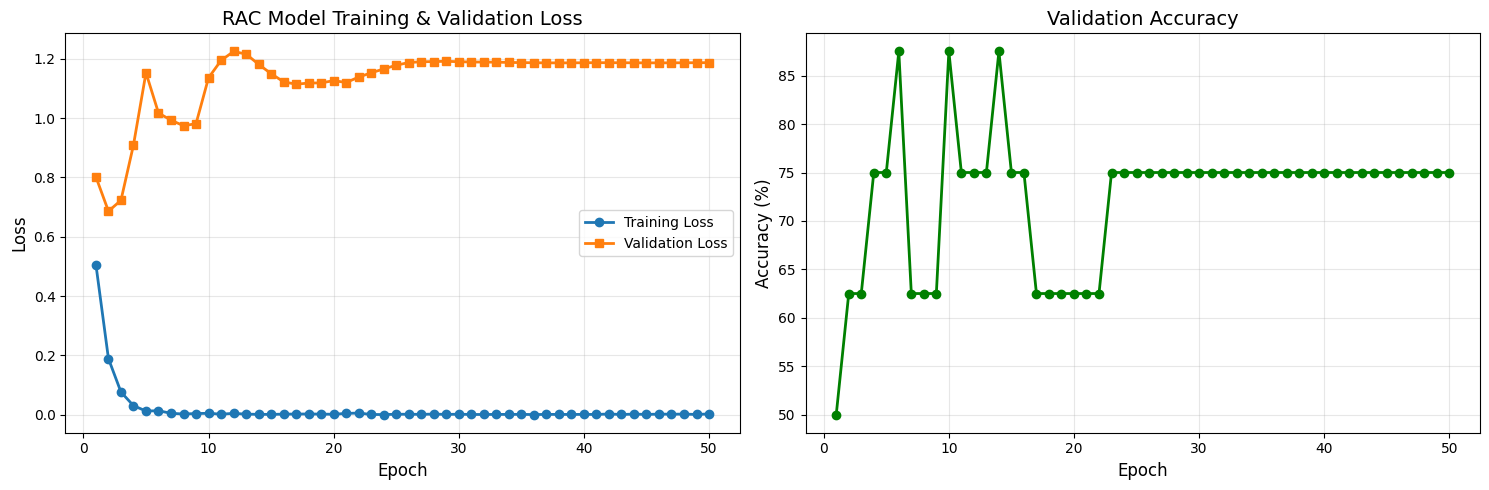


Final Results:
Best Validation Accuracy: 87.50% at Epoch 6
Final Validation Accuracy: 75.00%


In [39]:
num_epochs = 50
train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    # ===== TRAINING =====
    rac_model.train()
    total_train_loss = 0
    
    for data, labels in train_loader:
        optimizer.zero_grad()
        
        # Step A: Get Query Vector (from GAE)
        with torch.no_grad():
            v_query = gae_encoder(data.x, data.edge_index, data.edge_weight, data.batch)
        
        # Step B: Retrieve Neighbors from FAISS (Numpy step)
        v_query_np = v_query.cpu().numpy().astype('float32')
        distances, neighbor_indices = index.search(v_query_np, K)
        
        # Step C: Map indices back to the actual vectors (V_retrieved)
        v_retrieved = torch.from_numpy(kb_embeddings[neighbor_indices]).to(v_query.device)
        
        # Step D: Forward Pass
        predictions, _ = rac_model(data.x, data.edge_index, data.edge_weight, data.batch, v_retrieved)
        
        # Step E: Loss & Backprop
        loss = loss_fn(predictions.squeeze(), labels.float())
        loss.backward()
        torch.nn.utils.clip_grad_norm_(rac_model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # ===== VALIDATION =====
    rac_model.eval()
    total_val_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for data, labels in val_loader:
            # Get query vector
            v_query = gae_encoder(data.x, data.edge_index, data.edge_weight, data.batch)
            
            # Retrieve neighbors
            v_query_np = v_query.cpu().numpy().astype('float32')
            distances, neighbor_indices = index.search(v_query_np, K)
            v_retrieved = torch.from_numpy(kb_embeddings[neighbor_indices]).to(v_query.device)
            
            # Forward pass
            predictions, _ = rac_model(data.x, data.edge_index, data.edge_weight, data.batch, v_retrieved)
            
            # Calculate loss
            loss = loss_fn(predictions.squeeze(), labels.float())
            total_val_loss += loss.item()
            
            # Calculate accuracy
            predicted_labels = (predictions.squeeze() > 0.5).float()
            correct += (predicted_labels == labels.float()).sum().item()
            total += labels.size(0)
    
    avg_val_loss = total_val_loss / len(val_loader)
    val_accuracy = 100 * correct / total
    
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)
    
    # Update learning rate based on validation loss
    scheduler.step(avg_val_loss)
    
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracy:.2f}%")

# 8. Save the final trained RAC model
torch.save(rac_model.state_dict(), os.path.join(output_dir, 'rac_model.pth'))
print("RAC Model Training Complete and Saved.")

# 9. Visualize Training Loss and Validation Accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot losses
ax1.plot(range(1, num_epochs + 1), train_losses, marker='o', label='Training Loss', linewidth=2)
ax1.plot(range(1, num_epochs + 1), val_losses, marker='s', label='Validation Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('RAC Model Training & Validation Loss', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot validation accuracy
ax2.plot(range(1, num_epochs + 1), val_accuracies, marker='o', color='green', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Validation Accuracy', fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'rac_training_metrics.png'), dpi=300)
plt.show()

# Print final metrics
print(f"\nFinal Results:")
print(f"Best Validation Accuracy: {max(val_accuracies):.2f}% at Epoch {val_accuracies.index(max(val_accuracies)) + 1}")
print(f"Final Validation Accuracy: {val_accuracies[-1]:.2f}%")